# ClusterEnv — GRPO Scheduler Training

**Environment:** Power-Capped AI Cluster Scheduling Under Information Asymmetry  
**Agent:** Qwen2.5-3B-Instruct-bnb-4bit fine-tuned with GRPO (Group Relative Policy Optimization)  
**Task:** An LLM scheduler learns to allocate compute jobs across competing teams while one team systematically inflates priority claims.

## Prerequisites
- Runtime: **GPU** (T4 or better). Go to Runtime → Change runtime type → GPU.
- No credentials needed. All models and code are public.

## What this notebook does
1. Installs dependencies (Unsloth + ClusterEnv)
2. Downloads the pre-trained PPO cooling controller from HF Hub
3. Runs GRPO training for `N_ITERATIONS` iterations
4. Saves reward/loss curves and the trained LoRA adapter

> For judges re-running: the default config runs 10 iterations (~20 min on T4) to show convergence direction. Increase `N_ITERATIONS` to 30 for a full run.

## Step 1 — Install dependencies

In [1]:
%%capture
# Unsloth first (owns the torch version)
!pip install unsloth
# Everything else
!pip install stable-baselines3 gymnasium huggingface_hub trl accelerate bitsandbytes xformers matplotlib

## Step 2 — Clone the ClusterEnv repository

In [2]:
import os

REPO_URL    = "https://github.com/DrishyaShah/datacenter-env.git"
REPO_BRANCH = "arhaan/finale-v1"   # branch with all ClusterEnv code
REPO_DIR    = "/content/datacenter-env"

if not os.path.exists(REPO_DIR):
    !git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}
else:
    print(f"Repo already present at {REPO_DIR}")

os.chdir(REPO_DIR)
import sys
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print("Working dir:", os.getcwd())

Cloning into '/content/datacenter-env'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 87 (delta 2), reused 57 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 510.43 KiB | 17.60 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Filtering content: 100% (3/3), 1.00 MiB | 925.00 KiB/s, done.
Working dir: /content/datacenter-env


## Step 3 — Download PPO cooling controller from HF Hub

In [3]:
from huggingface_hub import hf_hub_download

ppo_dest = "training/cooling_controller_best/best_model.zip"
os.makedirs(os.path.dirname(ppo_dest), exist_ok=True)

if not os.path.exists(ppo_dest):
    hf_hub_download(
        repo_id   = "Mephisto2412/clusterenv-ppo-cooling",
        filename  = "best_model.zip",
        local_dir = "training/cooling_controller_best",
    )
    print("PPO model downloaded.")
else:
    print("PPO model already present.")

PPO model already present.


## Step 4 — Verify the environment works

In [4]:
from server.cluster_environment import ClusterEnvironment
from server.agents.baseline_scheduler import priority_weighted_threshold

env = ClusterEnvironment(enable_chiller_fault=False)
obs = env.reset(seed=0)
decisions = priority_weighted_threshold(obs)
obs2, reward, done, info = env.step(decisions)

print(f"Environment OK")
print(f"  Window 0 reward   : {reward:+.4f}")
print(f"  Window 1 state    : window_idx={obs2.window_idx}")
print(f"  Oversight flags   : {len(obs2.oversight_flags)} (Team B gaming detected)")

Environment OK
  Window 0 reward   : +0.0000
  Window 1 state    : window_idx=1
  Oversight flags   : 4 (Team B gaming detected)


## Step 5 — Configure training

In [5]:
# ── Training configuration ────────────────────────────────────────────────────
# Judges re-running: N_ITERATIONS=10 takes ~20 min on T4, shows convergence direction.
# Full run used N_ITERATIONS=30 on A10G (~2 hours).

MODEL_NAME       = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH   = 4096
N_ITERATIONS     = 30      # increase to 30 for full run
G_EPISODES       = 2       # episodes per iteration (2 = fast verification, 4 = full)
LEARNING_RATE    = 1e-5
TEMPERATURE      = 0.7
MAX_NEW_TOKENS   = 768
LORA_R           = 16
LORA_ALPHA       = 32
ADAPTER_DIR      = "training/grpo_adapter_colab"
CHECKPOINT_EVERY = 5

print(f"Model          : {MODEL_NAME}")
print(f"Iterations     : {N_ITERATIONS}")
print(f"Episodes/iter  : {G_EPISODES}  -> {G_EPISODES * 8} samples/iter")
print(f"Adapter output : {ADAPTER_DIR}")

Model          : unsloth/Qwen2.5-3B-Instruct-bnb-4bit
Iterations     : 30
Episodes/iter  : 2  -> 16 samples/iter
Adapter output : training/grpo_adapter_colab


## Step 6 — Load model with Unsloth

In [6]:
import warnings
warnings.filterwarnings("ignore", message=".*max_new_tokens.*max_length.*")
warnings.filterwarnings("ignore", category=FutureWarning)

import torch
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_dropout   = 0.0,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Trainable params: 29,933,568


## Step 7 — Run GRPO training

In [7]:
import numpy as np
from collections import defaultdict
from torch.optim import AdamW
from training.rollout import collect_rollouts, compute_grpo_advantages
from training.train_grpo import compute_log_prob, make_generate_fn

optimizer   = AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)
os.makedirs(ADAPTER_DIR, exist_ok=True)

reward_log, loss_log = [], []
generate_fn = make_generate_fn(model, tokenizer, TEMPERATURE, MAX_NEW_TOKENS)

for iteration in range(N_ITERATIONS):
    # — Rollout phase —
    rollouts   = collect_rollouts(generate_fn, n_episodes=G_EPISODES,
                                  base_seed=iteration * G_EPISODES,
                                  enable_chiller_fault=False)
    advantages = compute_grpo_advantages(rollouts)

    # — Gradient phase —
    FastLanguageModel.for_training(model)
    optimizer.zero_grad()
    total_loss = 0.0
    for sample, adv in zip(rollouts, advantages):
        lp   = compute_log_prob(model, tokenizer, sample["prompt"], sample["completion"])
        loss = (-adv * lp) / len(rollouts)
        loss.backward()
        total_loss += loss.item()
    grad_norm = torch.nn.utils.clip_grad_norm_(
        [p for p in model.parameters() if p.requires_grad], 1.0)
    optimizer.step()

    # — Logging —
    mean_reward    = float(np.mean([r["reward"] for r in rollouts]))
    parse_fails    = sum(1 for r in rollouts if r["reward"] <= -0.4)
    win_groups: dict[int, list[float]] = defaultdict(list)
    for r in rollouts:
        win_groups[r["window_idx"]].append(r["reward"])
    group_std = float(np.mean([np.std(v) for v in win_groups.values()]))

    reward_log.append(mean_reward)
    loss_log.append(total_loss)

    print(f"[{iteration+1:3d}/{N_ITERATIONS}]  "
          f"loss={total_loss:+.4f}  reward={mean_reward:+.4f}  "
          f"group_std={group_std:.3f}  grad={grad_norm:.3f}  "
          f"parse_fail={parse_fails}/{len(rollouts)}")

    if iteration < 2:
        preview = rollouts[0]["completion"].replace("\n", " ")[:100]
        print(f"  sample: {preview!r}")

    if (iteration + 1) % CHECKPOINT_EVERY == 0:
        ckpt = os.path.join(ADAPTER_DIR, f"ckpt_{iteration+1}")
        model.save_pretrained(ckpt)
        tokenizer.save_pretrained(ckpt)
        print(f"  Checkpoint -> {ckpt}")

print("\nTraining complete.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Cooling: PPO pretrained controller loaded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Both `max_new_tokens` (=768) and `max_length`(=1730) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=768) and `max_length`(=1937) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version

Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. Y

...

[ 29/30]  loss=-1.9453  reward=+0.0594  group_std=0.059  grad=29.561  parse_fail=0/16
Cooling: PPO pretrained controller loaded.


Both `max_new_tokens` (=768) and `max_length`(=1606) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=768) and `max_length`(=1888) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=768) and `max_length`(=2024) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=768) and `max_length`(=1842) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

[ 30/30]  loss=-0.3145  reward=+0.0250  group_std=0.037  grad=28.206  parse_fail=0/16


Unsloth: Restored added_tokens_decoder metadata in training/grpo_adapter_colab/ckpt_30/tokenizer_config.json.


  Checkpoint -> training/grpo_adapter_colab/ckpt_30

Training complete.


## Step 8 — Save training curves

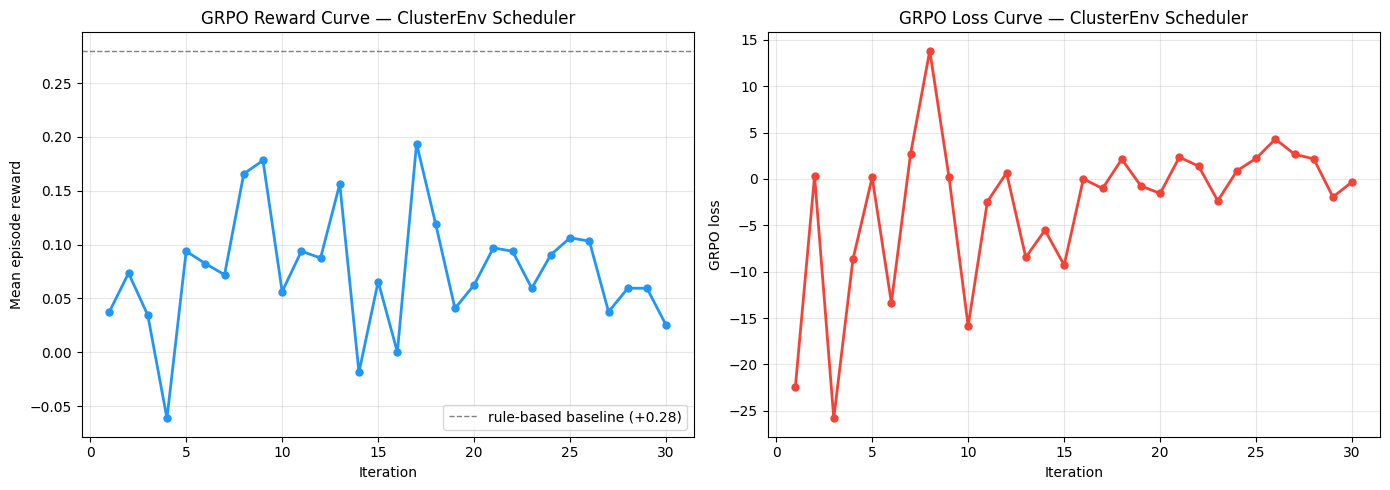

Saved: training/grpo_training_curves.png


In [8]:
import matplotlib.pyplot as plt

iters = list(range(1, len(reward_log) + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(iters, reward_log, color="#2196F3", linewidth=2, marker="o", markersize=5)
ax1.axhline(0.28, color="gray", linestyle="--", linewidth=1, label="rule-based baseline (+0.28)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Mean episode reward")
ax1.set_title("GRPO Reward Curve — ClusterEnv Scheduler")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(iters, loss_log, color="#F44336", linewidth=2, marker="o", markersize=5)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("GRPO loss")
ax2.set_title("GRPO Loss Curve — ClusterEnv Scheduler")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training/grpo_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training/grpo_training_curves.png")

## Step 9 — Save final adapter

In [ ]:
final_path = os.path.join(ADAPTER_DIR, "final")
model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)
print(f"Adapter saved -> {final_path}")

# Optional: push to HF Hub
# from huggingface_hub import login
# login()  # enter your token
# model.push_to_hub("Mephisto2412/clusterenv-grpo-adapter")
# tokenizer.push_to_hub("Mephisto2412/clusterenv-grpo-adapter")